# Las losowy

## Zadanie na 3

Implementacja lasu losowego

#### Import bibliotek

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification, make_moons, make_blobs
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from scipy.io import arff
from sklearn.model_selection import GridSearchCV

#### Funkcje do oceny skuteczności 

In [3]:
def plot_confusion_matrix(y_true, y_pred, labels=None):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format="d")
    plt.title("Macierz Pomyłek")
    plt.show()

def calculate_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    return accuracy, sensitivity, specificity

def plot_roc_curve(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Losowa klasyfikacja')
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Krzywa ROC')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

### Wygenerowanie danych

Jednomodowe - make_classification

In [4]:
my_index = 259199
my_n_samples = int(str(my_index)[0]+ str(my_index)[1] + str(my_index)[-2] + str(my_index)[-1])
X_classification, y_classification = make_classification(
    n_samples=my_n_samples, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0, 
    n_clusters_per_class=1, 
    random_state=my_index,
)

print('x', X_classification.shape)
print('y', y_classification.shape)

x (2599, 2)
y (2599,)


Jednomodowe - make_moons

In [5]:
X_moons, y_moons = make_moons(n_samples=my_n_samples, noise=0.2, random_state=my_index)

print('X_moons', X_moons.shape)
print('y_moons', y_moons.shape)

X_moons (2599, 2)
y_moons (2599,)


Wielomodowy - make_blobs

In [6]:
n_features = 2    
n_classes = 2     
n_clusters_per_class = 2

X_blobs, y_blobs = make_blobs(
    n_samples=my_n_samples,
    centers=n_classes * n_clusters_per_class,
    n_features=n_features,
    random_state=my_index
)

y_blobs = y_blobs % n_classes

#### Podział danych na treningowe i testowe

In [7]:
X_classification_train, X_classification_test, y_classification_train, y_classification_test = train_test_split(
    X_classification, y_classification, test_size=0.2, random_state=my_index
)

X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=my_index
)

X_blobs_train, X_blobs_test, y_blobs_train, y_blobs_test = train_test_split(
    X_blobs, y_blobs, test_size=0.2, random_state=my_index
)

print("classification:", X_classification_train.shape, y_classification_train.shape, X_classification_test.shape, y_classification_test.shape)
print("nmoons:", X_moons_train.shape, y_moons_train.shape, X_moons_test.shape, y_moons_test.shape)
print("blobs:", X_blobs_train.shape, y_blobs_train.shape, X_blobs_test.shape, y_blobs_test.shape)


classification: (2079, 2) (2079,) (520, 2) (520,)
nmoons: (2079, 2) (2079,) (520, 2) (520,)
blobs: (2079, 2) (2079,) (520, 2) (520,)


### Własna implementacja

#### Porównanie wyników 

Własna implementacja

In [8]:
results = pd.DataFrame(columns=["Accuracy", "Sensitivity", "Specificity"])


RandomForestClassifier

classification
Accuracy: 0.93, Sensitivity: 0.91, Specificity: 0.95


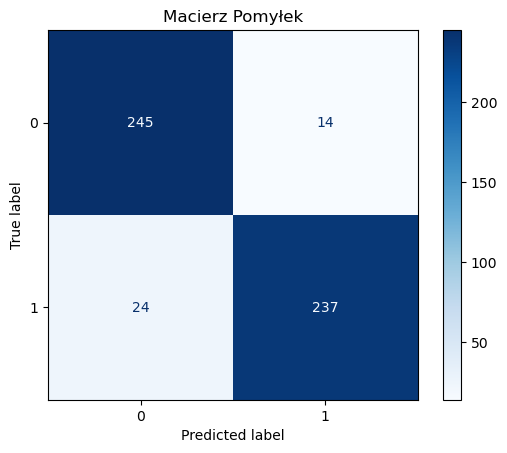

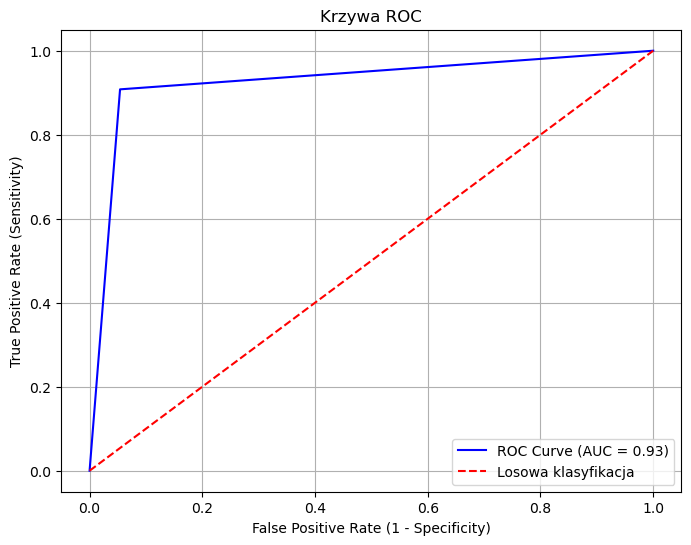

moons
Accuracy: 0.98, Sensitivity: 0.98, Specificity: 0.98


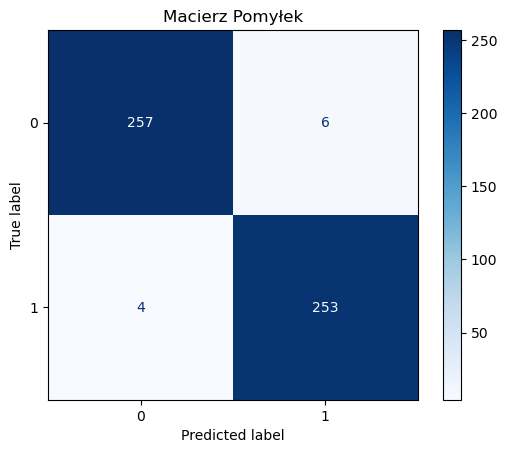

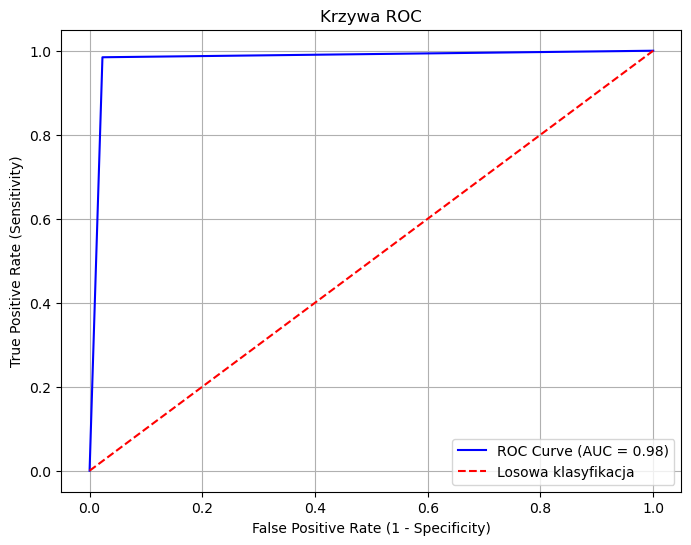

blobs
Accuracy: 0.88, Sensitivity: 0.88, Specificity: 0.89


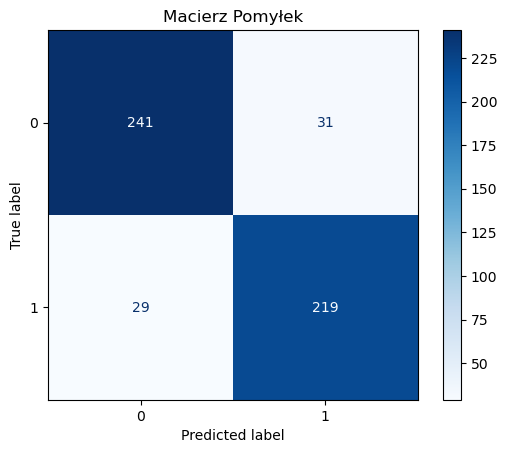

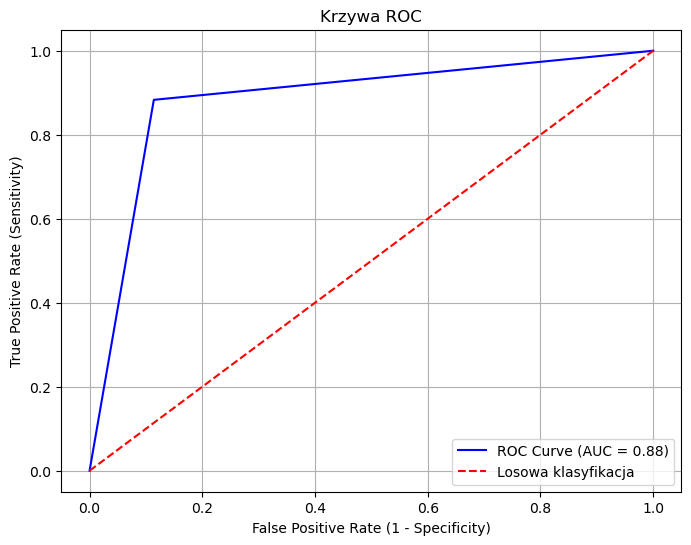

In [9]:
clf_classification = RandomForestClassifier(random_state=my_index)
clf_classification.fit(X_classification_train, y_classification_train)
y_pred_classification = clf_classification.predict(X_classification_test)

print("classification")
accuracy, sensitivity, specificity = calculate_metrics(y_classification_test, y_pred_classification)
print(f"Accuracy: {accuracy:.2f}, Sensitivity: {sensitivity:.2f}, Specificity: {specificity:.2f}")
results.loc["sklearn RF - classification"] = [accuracy, sensitivity, specificity]
plot_confusion_matrix(y_classification_test, y_pred_classification)
plot_roc_curve(y_classification_test, y_pred_classification)

clf_moons = RandomForestClassifier(random_state=my_index)
clf_moons.fit(X_moons_train, y_moons_train)
y_pred_moons = clf_moons.predict(X_moons_test)

print("moons")
accuracy, sensitivity, specificity = calculate_metrics(y_moons_test, y_pred_moons)
print(f"Accuracy: {accuracy:.2f}, Sensitivity: {sensitivity:.2f}, Specificity: {specificity:.2f}")
results.loc["sklearn RF - moons"] = [accuracy, sensitivity, specificity]
plot_confusion_matrix(y_moons_test, y_pred_moons)
plot_roc_curve(y_moons_test, y_pred_moons)

clf_blobs = RandomForestClassifier(random_state=my_index)
clf_blobs.fit(X_blobs_train, y_blobs_train)
y_pred_blobs = clf_blobs.predict(X_blobs_test)

print("blobs")
accuracy, sensitivity, specificity = calculate_metrics(y_blobs_test, y_pred_blobs)
print(f"Accuracy: {accuracy:.2f}, Sensitivity: {sensitivity:.2f}, Specificity: {specificity:.2f}")
results.loc["sklearn RF - blobs"] = [accuracy, sensitivity, specificity]
plot_confusion_matrix(y_blobs_test, y_pred_blobs)
plot_roc_curve(y_blobs_test, y_pred_blobs)

In [10]:
pd.DataFrame(results)

,Accuracy,Sensitivity,Specificity
sklearn RF - classification,0.926923,0.908046,0.945946
sklearn RF - moons,0.980769,0.984436,0.977186
sklearn RF - blobs,0.884615,0.883065,0.886029


## Zadanie na 4

Analiza zbioru NASA JPL Asteroid w oparciu o las losowy

#### Wczytanie danych 

In [11]:
file_path = f'./Datasets/NASA_JPL_asteroid.csv'
data = pd.read_csv(file_path, low_memory=False)

print(data.shape)
data.head()

(958524, 45)


,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


#### Sprawdzenie ilości brakujących wartości

In [12]:
missing_counts = data.isnull().sum()
missing_percent = 100 * missing_counts / len(data)
missing_table = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percent': missing_percent
})
missing_table = missing_table[missing_table['Missing Count'] > 0].sort_values(by='Missing Percent', ascending=False)
print('do usunięcia:', missing_table[missing_table['Missing Percent'] > 80].index.tolist())
missing_table

do usunięcia: ['prefix', 'name', 'albedo', 'diameter_sigma', 'diameter']


,Missing Count,Missing Percent
prefix,958506,99.998122
name,936460,97.698128
albedo,823421,85.905100
diameter_sigma,822443,85.803068
diameter,822315,85.789714
sigma_per,19926,2.078821
sigma_ad,19926,2.078821
sigma_i,19922,2.078404
sigma_q,19922,2.078404
sigma_a,19922,2.078404


#### Usunięcie kolumn 

z polecenia Orbit_id i full_name

również tych gdzie % brakujących wartości przekracza 80%

In [13]:
print(data.columns)

columns_to_drop = set(['id', 'full_name'] + missing_table[missing_table['Missing Percent'] > 80].index.tolist()) 
data = data.drop(columns=columns_to_drop)

data.head()

Index(['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'H',
       'diameter', 'albedo', 'diameter_sigma', 'orbit_id', 'epoch',
       'epoch_mjd', 'epoch_cal', 'equinox', 'e', 'a', 'q', 'i', 'om', 'w',
       'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld',
       'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w',
       'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class',
       'rms'],
      dtype='object')


,spkid,pdes,neo,pha,H,orbit_id,epoch,epoch_mjd,epoch_cal,equinox,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,2000001,1,N,N,3.40,JPL 47,2458600.5,58600,20190427.0,J2000,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,2000002,2,N,N,4.20,JPL 37,2459000.5,59000,20200531.0,J2000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,2000003,3,N,N,5.33,JPL 112,2459000.5,59000,20200531.0,J2000,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,2000004,4,N,N,3.00,JPL 35,2458600.5,58600,20190427.0,J2000,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,2000005,5,N,N,6.90,JPL 114,2459000.5,59000,20200531.0,J2000,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


#### Usunięcie wierszy z brakującymi wartościami w 'neo' lub 'pha'


In [14]:
data = data.dropna(subset=['neo', 'pha'])

data = data.reset_index(drop=True)
print(data.shape)

(938599, 38)


#### Podział na x i y 

In [15]:
X = data.drop(columns=['pha', 'neo'])
y_neo = data['neo']
y_pha = data['pha']

print(X.shape, y_pha.shape, y_neo.shape)

(938599, 36) (938599,) (938599,)


Wylistowanie kolumn kategorycznych i numerycznych 

In [16]:
categorical_columns = X.select_dtypes(include=['object']).columns
print('Categorical columns:', categorical_columns)

numerical_columns = X.select_dtypes(include=['float64', 'int64']).columns
print('Numerical columns:', numerical_columns)

Categorical columns: Index(['pdes', 'orbit_id', 'equinox', 'class'], dtype='object')
Numerical columns: Index(['spkid', 'H', 'epoch', 'epoch_mjd', 'epoch_cal', 'e', 'a', 'q', 'i',
       'om', 'w', 'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid',
       'moid_ld', 'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om',
       'sigma_w', 'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per',
       'rms'],
      dtype='object')


#### Imputacja brakujących wartości

In [17]:
missing_values_before = X.isnull().sum()
missing_values_before = missing_values_before[missing_values_before > 0]

for col in categorical_columns:
    mode_value = X[col].mode()[0]
    X[col].fillna(mode_value, inplace=True)

for col in numerical_columns:
    median_value = X[col].median()
    X[col].fillna(median_value, inplace=True)

missing_values_after = X.isnull().sum()

comparison_table = pd.DataFrame({
    'Column': missing_values_before.index,
    'Missing Before': missing_values_before.values,
    'Missing After': missing_values_after[missing_values_before.index].values
})

print(comparison_table)

       Column  Missing Before  Missing After
0           H            6262              0
1          ma               1              0
2     sigma_e               1              0
3     sigma_a               1              0
4     sigma_q               1              0
5     sigma_i               1              0
6    sigma_om               1              0
7     sigma_w               1              0
8    sigma_ma               1              0
9    sigma_ad               1              0
10    sigma_n               1              0
11   sigma_tp               1              0
12  sigma_per               1              0
13        rms               1              0


#### Podział danych na treningowe i testowe dla neo

In [18]:
X_neo_train, X_neo_test, y_neo_train, y_neo_test = train_test_split(X, y_neo, test_size=0.2, random_state=my_index)

print(X_neo_train.shape, y_neo_train.shape, X_neo_test.shape, y_neo_test.shape)

(750879, 36) (750879,) (187720, 36) (187720,)


#### Opytmalny podział hiperparametrów

In [ ]:
param_grid = {
    'n_estimators': [50, 100],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=my_index)
grid_search = GridSearchCV(rf, param_grid, n_jobs=1)
grid_search.fit(X_neo_train, y_neo_train)

print("Najlepsze parametry:", grid_search.best_params_)

ValueError: 
All the 240 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
48 fits failed with the following error:
Traceback (most recent call last):
  File "d:\anaconda\Lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\anaconda\Lib\site-packages\sklearn\ensemble\_forest.py", line 331, in fit
    X, y = self._validate_data(
           ^^^^^^^^^^^^^^^^^^^^
  File "d:\anaconda\Lib\site-packages\sklearn\base.py", line 596, in _validate_data
    X, y = check_X_y(X, y, **check_params)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\anaconda\Lib\site-packages\sklearn\utils\validation.py", line 1074, in check_X_y
    X = check_array(
        ^^^^^^^^^^^^
  File "d:\anaconda\Lib\site-package

#### Wyniki dla neo

In [ ]:
best_rf = grid_search.best_estimator_
y_pred_neo = best_rf.predict(X_neo_test)

print("neo")
accuracy, sensitivity, specificity = calculate_metrics(y_neo_test, y_pred_neo)
print(f"Accuracy: {accuracy:.2f}, Sensitivity: {sensitivity:.2f}, Specificity: {specificity:.2f}")
plot_confusion_matrix(y_neo_test, y_pred_neo)
plot_roc_curve(y_neo_test, y_pred_neo)

AttributeError: 'GridSearchCV' object has no attribute 'best_estimator_'

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Przygotowanie danych: klasyfikacja NEO (neo == 'Y' to NEO, reszta to nie-NEO)
y_neo = (X['neo'] == 'Y').astype(int)
X_neo = X.drop(columns=['neo'])  # Usuwamy kolumnę 'neo' z cech

# Podział na zbiór treningowy i testowy
X_neo_train, X_neo_test, y_neo_train, y_neo_test = train_test_split(
    X_neo, y_neo, test_size=0.2, random_state=my_index
)

# One-hot encoding dla cech kategorycznych
X_neo_train_enc = pd.get_dummies(X_neo_train, columns=categorical_columns.drop('neo'))
X_neo_test_enc = pd.get_dummies(X_neo_test, columns=categorical_columns.drop('neo'))

# Dopasowanie kolumn (mogą się różnić po one-hot encodingu)
X_neo_train_enc, X_neo_test_enc = X_neo_train_enc.align(X_neo_test_enc, join='left', axis=1, fill_value=0)

# Parametry do przeszukania
param_grid = {
    'n_estimators': [50, 100],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=my_index, n_jobs=-1)
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='accuracy', verbose=2)
grid_search.fit(X_neo_train_enc, y_neo_train)

print("Najlepsze parametry:", grid_search.best_params_)
print("Najlepszy wynik (accuracy):", grid_search.best_score_)

# Uczenie modelu z najlepszymi parametrami
best_rf = grid_search.best_estimator_
y_neo_pred = best_rf.predict(X_neo_test_enc)

accuracy, sensitivity, specificity = calculate_metrics(y_neo_test, y_neo_pred)
print(f"Test accuracy: {accuracy:.4f}, sensitivity: {sensitivity:.4f}, specificity: {specificity:.4f}")

plot_confusion_matrix(y_neo_test, y_neo_pred, labels=["not NEO", "NEO"])
plot_roc_curve(y_neo_test, best_rf.predict_proba(X_neo_test_enc)[:, 1])